In [2]:
!pip install xlrd
!pip install openpyxl
import pandas as pd
import unicodedata
from pathlib import Path

Plusieurs jeux de données sont mobilisés ci-dessous : 
- les résultats des élections municipales
- les listes des municipales, pour récupérer les couleurs politiques de tous les élus municipaux pour les interco
- la liste des présidents d'interco, pour donner une couleur politique aux interco
- la correspondance entre EPCI et communes appartenant à l'interco
- la correspondance entre code Insee et code postal

In [3]:
#creation d'une fonction pour détecter là où débute vraiment le fichier
def detecter_ligne_header(fichier, mot_cle="Critère d'export", limite=15):
    preview = pd.read_excel(fichier, header=None, nrows=limite)

    for idx, row in preview.iterrows():
        if mot_cle in row.astype(str).values:
            return idx
    return 0

In [4]:
def simplifier_prenom(text):
    if pd.isna(text):
        return None   # ou "" ou text
    # Normalise en forme NFD (décompose les accents)
    text_normalized = unicodedata.normalize('NFD', text)
    # Garde seulement les caractères ASCII (supprime les accents)
    text_ascii = text_normalized.encode('ascii', 'ignore').decode('utf-8')
    text_clean = text_ascii.replace('-', ' ')
    return text_clean

### Importation données listes municipales 2014

In [5]:
# Dossier contenant uniquement les fichiers à importer
dossier_listes_2014 = Path("/home/onyxia/work/projet3A/donnees_electorales/donnees listes municipales 2014")

# Liste de tous les fichiers du dossier
fichiers_2014 = dossier_listes_2014.iterdir()

dfs = []

for f in fichiers_2014:
    ligne_header = detecter_ligne_header(f)
    df = pd.read_excel(f, header=ligne_header)
    df["source"] = f.name  # optionnelle
    dfs.append(df)

df_listes_muni_2014 = pd.concat(dfs, ignore_index=True)

print("Dimensions :", df_listes_muni_2014.shape)

Dimensions : (520074, 16)


On garde uniquement les infos sur la ville, la liste et le numéro dans la liste de chaque personne sur une liste municipale

In [6]:
df_listes_muni_2014.drop(labels = [ "Critère d'export", 'Libellé du département','Libellé commune', 'N° Panneau Liste', 'Code Dépôt',
       'Libellé abrégé liste', 'Libellé Etendu Liste',
       'Sexe', 'Nationalité',
       'Candidat au conseil communautaire', 'source'],axis = 1, inplace=True)

Importation du jeu de données contenant les résultats de toutes les élections (sauf municipales de 2014 qui sont manquantes)

In [7]:
all_elections = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/candidats_results.txt", sep=";")
#mini modif manuelle à cause d'une erreur
all_elections.loc[22340396, 'Binôme'] = all_elections.loc[22160435, 'Binôme']

/tmp/ipykernel_360698/3451900702.py:1: DtypeWarning: Columns (2,4,6,7,8,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  all_elections = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/candidats_results.txt", sep=";")


In [8]:
muni_2014 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/MN14_Bvot_T1T2.txt", sep=";",
    encoding="latin-1", skiprows=17, header= None)
muni_2014.columns = ['id_tour', 'Code du département', 'Code de la commune', 'Nom de la commune',
'Code du b.vote', 'Inscrits', 'Votants', 'Exprimes', 'num liste', 'Prénom', 'Nom', 'Nuance', 'Voix']
muni_2014['id_tour'] = "t" + muni_2014['id_tour'].astype(str)
print(muni_2014.shape)

#On supprime tous les candidats de liste sans nuance politique !!! 
muni_2014 = muni_2014[muni_2014['Nuance'] != "NC"]
print(muni_2014.shape)

/tmp/ipykernel_360698/874599522.py:1: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  muni_2014 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/MN14_Bvot_T1T2.txt", sep=";",


(692029, 13)
(206898, 13)


## Etape initiale : constituer une liste des nuances de tous les candidats

##### Traitement des données des candidats aux départementales, qui ont un format "binome"

In [9]:
elec_binome = all_elections[all_elections["Binôme"].notna()]
liste_elec_binome = elec_binome['id_election'].unique()
election_dep = all_elections[all_elections['id_election'].isin(liste_elec_binome)]
election_dep.drop_duplicates(subset=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], inplace=True)
election_dep = election_dep[["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"]]
election_dep[["candidat1", "candidat2"]] = election_dep["Binôme"].str.split(" et ", expand=True)

# Enlever les titres "M" ou "Mme" au début
election_dep["candidat1"] = election_dep["candidat1"].str.replace(r"^(M\.|Mme)\s+", "", regex=True)
election_dep["candidat2"] = election_dep["candidat2"].str.replace(r"^(M\.|Mme)\s+", "", regex=True)

election_dep[[ "nom1", "prenom1"]] = election_dep["candidat1"].str.split(" ", n=1, expand=True)
election_dep["prenom1"] = election_dep["prenom1"].str.lower()
election_dep[[ "nom2","prenom2"]] = election_dep["candidat2"].str.split(" ", n=1, expand=True)
election_dep["prenom2"] = election_dep["prenom2"].str.lower()

election_dep_long = pd.wide_to_long(election_dep, 
                          stubnames=["prenom", "nom"], 
                          i=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], 
                          j="num_binôme",   # nouveau suffixe qui indiquera 1 ou 2
                          sep="")    # pas de séparateur entre stubname et numéro

# Réinitialiser l'index pour obtenir un DataFrame classique
election_dep_long = election_dep_long.reset_index()
election_dep_long['Nuance'] = election_dep_long['Nuance'].str.replace(r'^BC-', '', regex=True)
election_dep_long.drop(['Binôme', 'num_binôme', 'candidat1', 'candidat2'], axis = 1, inplace= True)

/tmp/ipykernel_360698/678289474.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  election_dep.drop_duplicates(subset=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], inplace=True)


##### Traitement des candidats hors municipales et départementales

In [10]:
election_hors_dep = all_elections[~all_elections['id_election'].isin(liste_elec_binome)]
election_hors_dep_et_muni = election_hors_dep[election_hors_dep["id_election"].str.contains("muni", case=False, na=False)]
election_hors_dep_et_muni = election_hors_dep_et_muni[['id_election', 'id_brut_miom', 'Code du département', 'Nom', 'Prénom', 'Nuance']]

In [11]:
election_dep_long.rename(columns={'prenom': 'Prénom'}, inplace=True)
election_dep_long.rename(columns={'nom': 'Nom'}, inplace=True)
election_dep_long.rename(columns={'Code du département': 'dep'}, inplace=True)
election_hors_dep_et_muni.rename(columns={'Code du département': 'dep'}, inplace=True)
liste_candidats_nuance_hors_muni = pd.concat([election_dep_long, election_hors_dep_et_muni], ignore_index=True)
liste_candidats_nuance_hors_muni['annee'] = liste_candidats_nuance_hors_muni['id_election'].str[:4]
liste_candidats_nuance_hors_muni.head()

,id_election,id_brut_miom,dep,Nuance,Prénom,Nom,annee
0,2021_dpmt_t2,01001_0001,01,UCD,patricia,CHMARA,2021
1,2021_dpmt_t2,01001_0001,01,UCD,patrick,MATHIAS,2021
2,2021_dpmt_t2,01002_0001,01,UG,fabrice,PEREYRON,2021
3,2021_dpmt_t2,01002_0001,01,UG,marie-céline,RAY,2021
4,2021_dpmt_t2,01004_0001,01,UG,fabrice,PEREYRON,2021


### On s'intéresse au score des municipales

In [66]:
muni_2014["ident_election_ville"].unique()

array(['14', '15', '17', ..., '872', '8711', '8748'],
      shape=(6075,), dtype=object)

In [67]:
muni_2014.head()

,id_tour,Code du département,Code de la commune,Nom de la commune,Code du b.vote,Inscrits,Votants,Exprimes,num liste,Prénom,Nom,Nuance,Voix,id_brut_miom,id_election,ident_election_ville
27,t1,1,4,Ambérieu-en-Bugey,0001,1011,565,539,3,PIDOUX,Catherine,LDVG,92,14_0001,2014_muni_t1,14
28,t1,1,4,Ambérieu-en-Bugey,0001,1011,565,539,5,FORTIN,Christophe,LUMP,164,14_0001,2014_muni_t1,14
29,t1,1,4,Ambérieu-en-Bugey,0001,1011,565,539,4,FABRE,Daniel,LDVD,169,14_0001,2014_muni_t1,14
30,t1,1,4,Ambérieu-en-Bugey,0001,1011,565,539,2,EXPOSITO,Josiane,LDVG,114,14_0001,2014_muni_t1,14
31,t1,1,4,Ambérieu-en-Bugey,0002,1104,660,638,5,FORTIN,Christophe,LUMP,190,14_0002,2014_muni_t1,14


In [12]:
muni_2014['id_brut_miom'] = muni_2014['Code du département'].astype(str) + muni_2014['Code de la commune'].astype(str) + "_" + muni_2014['Code du b.vote'].astype(str)
muni_2014['id_election'] = "2014_muni_" + muni_2014['id_tour'].astype(str)
muni_2014['ident_election_ville'] = muni_2014["id_brut_miom"].str[:-5]

In [13]:
donnees_restreintes_muni = all_elections[all_elections["id_election"].str.contains("muni", case=False, na=False)]
donnees_restreintes_muni['ident_election_ville'] = donnees_restreintes_muni["id_brut_miom"].str[:5]

#à nouveau, on enlève les candidats où il n'y a pas de nuance politique 
print(donnees_restreintes_muni.shape)
donnees_restreintes_muni = donnees_restreintes_muni[donnees_restreintes_muni['Nuance'] != 'NC']
print(donnees_restreintes_muni.shape)
donnees_restreintes_muni = donnees_restreintes_muni[donnees_restreintes_muni['Nuance'] != 'LNC']
print(donnees_restreintes_muni.shape)

/tmp/ipykernel_360698/8394975.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  donnees_restreintes_muni['ident_election_ville'] = donnees_restreintes_muni["id_brut_miom"].str[:5]


(1463530, 19)
(569471, 19)
(549196, 19)


In [14]:
donnees_restreintes_muni['Nuance'].unique()

array(['LDIV', 'LDVC', 'LDVD', 'LDVG', 'LLR', 'LEXD', 'LRN', 'LECO',
       'LUG', 'LSOC', 'LUD', 'LCOM', 'LREM', 'LVEC', 'LMDM', 'LUC',
       'LEXG', 'LUDI', 'LFI', 'LREG', 'LDLF', 'LGJ', 'LAUT', 'LMAJ',
       'LGC', 'LMC', 'LCMD', 'LFN', 'LRDG', '2', 'LUMP', 'LFG', 'LPG'],
      dtype=object)

In [15]:
donnees_muni = pd.concat([donnees_restreintes_muni,muni_2014])

In [16]:
# ---- Étape 1 : calcul des voix totales par élection et ville ----
voix_totales = (
    donnees_muni
    .groupby(["id_election", "ident_election_ville"], as_index=False)
    .agg(voix_total_ville_elec=("Voix", "sum"))
)

In [73]:
print(voix_totales[voix_totales['id_election'] == '2014_muni_t1'].shape)
print(voix_totales[voix_totales['id_election'] == '2020_muni_t1'].shape)

(11897, 3)
(3182, 3)


En 2025, environ 24000 ont moins de 1000 habitants, cohérent avec la stat de presque 12000 communes en 2014 dans nos données
idem pour 2020, puisqu'en 2025 environ 31500 communes ont moins 

In [18]:
# ---- Étape 2 : calcul des voix par candidat ----
donnees_muni_long = (
    donnees_muni
    .groupby(["id_election", "ident_election_ville", "Nom", "Prénom", "Nuance"], as_index=False)
    .agg(voix_totales_candidat=("Voix", "sum"))
    .merge(voix_totales, on=["id_election", "ident_election_ville"], how="left")
    .assign(voix_pct=lambda d: d["voix_totales_candidat"] / d["voix_total_ville_elec"] * 100)
    .sort_values(["id_election", "ident_election_ville", "voix_pct"], ascending=[True, True, False])
)

# ---- Étape 3 : classement des deux premiers ----
donnees_muni_wide = (
    donnees_muni_long
    .assign(rang=lambda d: d.groupby(["id_election", "ident_election_ville"]).cumcount() + 1)
    .query("rang <= 2")
    .pivot(index=["id_election", "ident_election_ville"],
           columns="rang",
           values=["Prénom", "Nom", "Nuance","voix_pct"])
)

# Aplatir les noms de colonnes hiérarchiques comme "rang1_Prénom"
donnees_muni_wide.columns = [
    f"rang{r}_{v}" for v, r in donnees_muni_wide.columns
]
donnees_muni_wide = donnees_muni_wide.reset_index()

# ---- Étape 5 : extraire les variables election / tour ----
donnees_muni_wide = (
    donnees_muni_wide
    .assign(
        election=lambda d: d["id_election"].str[:9],
        tour=lambda d: d["id_election"].str[10:12])
    .groupby(["election", "ident_election_ville"], group_keys=False)
    .filter(lambda g: not ("t1" in g["tour"].values and "t2" in g["tour"].values and g["tour"].eq("t1").any()))
)


In [85]:
donnees_muni_wide.head()

,id_election,ident_election_ville,rang1_Prénom,rang2_Prénom,rang1_Nom,rang2_Nom,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct,election,tour
1,2008_muni_t1,01014,Liliane,Michel,MAISSIAT,GAUTHIER,LMAJ,LDVD,78.73701,21.26299,2008_muni,t1
2,2008_muni_t1,01033,Régis,Guy,PETIT,LARMANJAT,LMAJ,LSOC,58.224883,41.775117,2008_muni,t1
5,2008_muni_t1,01053,Jean-François,Christophe,DEBAT,FEILLENS,LSOC,LMAJ,55.371775,34.802731,2008_muni,t1
7,2008_muni_t1,01142,Bernard,Bernard,SIMPLEX,LOBIETTI,LDVD,LMAJ,58.760951,41.239049,2008_muni,t1
8,2008_muni_t1,01143,Etienne,NaN,BLANC,NaN,LMAJ,NaN,100.0,NaN,2008_muni,t1


In [19]:
#on prépare la suite en créant un fichier listant les têtes de liste des municipales et leur couleur politique
liste_candidats_nuance_muni = (
                    donnees_muni_long
                    .assign(annee = lambda d : d["id_election"].str[0:4])
                    .assign(dep = lambda d : d["ident_election_ville"].str[0:2])
                    .loc[:, ["id_election", "ident_election_ville","annee","dep", "Nom", "Prénom", "Nuance"]]
)
liste_candidats_nuance_muni.head(20)


,id_election,ident_election_ville,annee,dep,Nom,Prénom,Nuance
1,2008_muni_t1,01004,2008,01,EXPOSITO,Josiane,LUG
0,2008_muni_t1,01004,2008,01,CASTELLANO,Sandrine,LDVD
2,2008_muni_t1,01004,2008,01,PAVIER,Bernard,LGC
3,2008_muni_t1,01004,2008,01,SASSO,Jean-Marc,LDVD
5,2008_muni_t1,01014,2008,01,MAISSIAT,Liliane,LMAJ
4,2008_muni_t1,01014,2008,01,GAUTHIER,Michel,LDVD
7,2008_muni_t1,01033,2008,01,PETIT,Régis,LMAJ
6,2008_muni_t1,01033,2008,01,LARMANJAT,Guy,LSOC
10,2008_muni_t1,01034,2008,01,TRAVERS,Jean-Claude,LMAJ
9,2008_muni_t1,01034,2008,01,FOGNINI,Jean-Marc,LDVG


In [80]:
liste_candidats_nuance_muni[liste_candidats_nuance_muni['annee'] == "2020"]['ident_election_ville'].describe()

count     12788
unique     3182
top       75056
freq        231
Name: ident_election_ville, dtype: object

Retour aux listes des municipales

In [25]:
df_listes_muni_2014.head()
df_listes_muni_2014['ident_election_ville'] = df_listes_muni_2014['Code du département'].astype(str).str.zfill(2) + df_listes_muni_2014['Code commune'].astype(str).str.zfill(3)


In [26]:
# Harmonisation de sécurité (évite erreurs minuscules/majuscules/espaces)
for col in ["ident_election_ville", "Nom", "Prénom"]:
    df_listes_muni_2014[col] = df_listes_muni_2014[col].astype(str).str.strip().str.upper()
    liste_candidats_nuance_muni[col] = liste_candidats_nuance_muni[col].astype(str).str.strip().str.upper()

# On récupère uniquement les têtes (ordre = 1)
tetes_listes_ss_nuance_2014 = df_listes_muni_2014[df_listes_muni_2014['N° du candidat dans la liste'] == 1].copy()
#tetes_listes_ss_nuance.drop(tetes_listes_ss_nuance[tetes_listes_ss_nuance["commune"] == "PARIS"].index)
tetes_listes_ss_nuance_2014.drop(labels = ['N° du candidat dans la liste', 'Code du département', 'Code commune'],
 axis = 1, inplace=True)
tetes_listes_ss_nuance_2014['annee'] = '2014'

In [27]:
liste_candidats_nuance_muni_2014 = liste_candidats_nuance_muni.drop(liste_candidats_nuance_muni[liste_candidats_nuance_muni["id_election"] == "2014_muni_t2"].index,
                                axis = 0)

In [28]:
# On ajoute leur nuance depuis la base des nuances
tetes_listes_avec_nuance_2014 = tetes_listes_ss_nuance_2014.merge(
    liste_candidats_nuance_muni_2014[["ident_election_ville", "Nom", "Prénom", "Nuance", "annee"]],
    on=["ident_election_ville", "Nom", "Prénom", "annee"],
    how="left"
)

In [29]:
# On garde uniquement commune + tête + nuance
tetes_listes_avec_nuance_2014 = tetes_listes_avec_nuance_2014[[
    "ident_election_ville",
    "Nom",
    "Prénom",
    "Nuance"
]]

#Pour chaque TETE DE LISTE, on associe sa nuance
liste_candidats_muni_2014_avec_nuance = df_listes_muni_2014.merge(
    tetes_listes_avec_nuance_2014,
    on=["ident_election_ville", "Nom", "Prénom"],
    how="left"
)

print(liste_candidats_muni_2014_avec_nuance.head(40))
#print("\nRépartition des nuances :")
#print(df_listes_muni_2014_avec_nuance["Nuance"].value_counts(dropna=False))


   Code du département Code commune  N° du candidat dans la liste  \
0                    1            4                             1   
1                    1            4                             2   
2                    1            4                             3   
3                    1            4                             4   
4                    1            4                             5   
5                    1            4                             6   
6                    1            4                             7   
7                    1            4                             8   
8                    1            4                             9   
9                    1            4                            10   
10                   1            4                            11   
11                   1            4                            12   
12                   1            4                            13   
13                   1            

In [30]:
#on répercute à l'ensemble des colistiers la nuance de la tête de liste
liste_candidats_muni_2014_avec_nuance["Nuance"] = liste_candidats_muni_2014_avec_nuance["Nuance"].ffill()
liste_candidats_muni_2014_avec_nuance['dep'] = liste_candidats_muni_2014_avec_nuance['Code du département'].astype(str).str.zfill(2) 
liste_candidats_muni_2014_avec_nuance.head(40)
liste_candidats_muni_2014_avec_nuance.drop(labels=['N° du candidat dans la liste', 'Code commune', 'Code du département'], axis = 1, inplace=True)

In [31]:
liste_candidats_muni_2014_avec_nuance['annee'] = "2014"
liste_candidats_muni_2014_avec_nuance.head()

,Nom,Prénom,ident_election_ville,Nuance,dep,annee
0,PIDOUX,CATHERINE,01004,LDVG,01,2014
1,FONTANIERE,BERNARD,01004,LDVG,01,2014
2,METRAL,LAURENCE,01004,LDVG,01,2014
3,GUERRY,JOËL,01004,LDVG,01,2014
4,GAGER,BARBARA,01004,LDVG,01,2014


#### dernière information à récupérer : liste des élections municipales de 2020

In [32]:
df_listes_muni_2020 = pd.read_excel("/home/onyxia/work/projet3A/donnees_electorales/livre-des-listes-et-candidats_2020.xlsx",
                                skiprows = 2)
df_listes_muni_2020 = df_listes_muni_2020.rename(columns={"N° candidat": "N° du candidat dans la liste",
                        'Prénom candidat':'Prénom',
                        'Nom candidat' : 'Nom',
                        'Nuance Liste' : 'Nuance'})
df_listes_muni_2020['annee'] = "2020"           

In [33]:
df_listes_muni_2020['ident_election_ville'] = df_listes_muni_2020['Code du département'].astype(str).str.zfill(2) + df_listes_muni_2020['Code commune'].astype(str).str.zfill(3)
df_listes_muni_2020['dep'] = df_listes_muni_2020['Code du département'].astype(str).str.zfill(2) 
df_listes_muni_2020.drop(labels = ['Libellé du département', 'Code commune', 'Libellé commune',
       'N° Panneau Liste', 'Libellé abrégé liste', 'Libellé Etendu Liste', 'Code du département',
       'N° du candidat dans la liste', 'Sexe candidat', 'Nationalité', 'Candidat au conseil communautaire'],
       axis = 1, inplace= True)

## Fusion de toutes les informations sur les nuances politiques

In [34]:
liste_candidats_nuance = pd.concat([liste_candidats_nuance_hors_muni,liste_candidats_nuance_muni,
liste_candidats_muni_2014_avec_nuance,df_listes_muni_2020], ignore_index=True)
liste_candidats_nuance.head()
liste_candidats_nuance['prenom'] =liste_candidats_nuance['Prénom'].str.lower().apply(simplifier_prenom)
liste_candidats_nuance['nom'] =liste_candidats_nuance['Nom'].str.lower().apply(simplifier_prenom)
liste_candidats_nuance.dropna(subset=['prenom'], inplace=True)
liste_candidats_nuance.drop(columns=["id_election","id_brut_miom","ident_election_ville","Prénom", "Nom"], inplace=True)
liste_candidats_nuance.drop_duplicates(inplace=True)


Importation des données des intercommunalités

In [35]:
#grp_2013 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/Liste_des_groupements_en_2013.csv", encoding="latin-1", sep = ";")
grp_2019 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/Liste_des_groupements_en_2019.csv", encoding="latin-1", sep = ";")
grp_2025 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/Liste_des_groupements_en_2024.csv", encoding="latin-1", sep = ";")
#grp_2013['annee'] = "2008"
grp_2019['annee'] = "2014"
grp_2025['annee'] = "2020"

liste_grps = [grp_2019, grp_2025] #grp_2013,

for df in liste_grps:
    df['Nom Président'] = df['Nom Président'].str.lower().apply(simplifier_prenom)
    df['prenom'] = df['Prénom Président'].str.lower().apply(simplifier_prenom)
    df['dep'] = df["Département siège"].str[:2]
    df['annee'] = df['annee'].astype(int)
    df['dep'] = df['dep'].astype(str)
    df = df.sort_values("annee")



In [36]:
liste_candidats_nuance['annee'] = liste_candidats_nuance['annee'].astype(int)
liste_candidats_nuance['dep'] = liste_candidats_nuance['dep'].astype(str)
liste_candidats_nuance = liste_candidats_nuance.sort_values("annee")

In [37]:
#on fusionne notre groupement entre les présidents des interco et nos candidats aux municipales 
#cette fusion est "au plus proche"
grp_2019_avec_nuance_test_proxi = pd.merge_asof(
    grp_2019,
    liste_candidats_nuance,
    on="annee",          # recherche de l'année la plus proche
    left_by=["prenom", "Nom Président", "dep"],
    right_by=["prenom", "nom", "dep"],
    direction="nearest"   # année la plus proche (avant ou après)
)

grp_2025_avec_nuance_test_proxi = pd.merge_asof(
    grp_2025,
    liste_candidats_nuance,
    on="annee",          # recherche de l'année la plus proche
    left_by=["prenom", "Nom Président", "dep"],
    right_by=["prenom", "nom", "dep"],
    direction="nearest"   # année la plus proche (avant ou après)
)

In [38]:
print(grp_2019.shape)
print(grp_2019_avec_nuance_test_proxi.shape)
print(grp_2019_avec_nuance_test_proxi['Nuance'].isna().sum())
print(grp_2025.shape)
print(grp_2025_avec_nuance_test_proxi.shape)
print(grp_2025_avec_nuance_test_proxi['Nuance'].isna().sum())

(11226, 23)
(11226, 25)
1772
(9884, 23)
(9884, 25)
1536


In [39]:
grp_all_annee_avec_nuance = pd.concat([grp_2019_avec_nuance_test_proxi, grp_2025_avec_nuance_test_proxi]
                            , ignore_index=True)

grp_all_annee_avec_nuance['N° SIREN'] = grp_all_annee_avec_nuance['N° SIREN'].astype(str)

#### On veut un jeu de données avec 
commune - annee - couleur maire - score maire aux municipales - couleur interco

In [41]:
table_correspondance_epci_commune = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/perimetre-epci-a-fp.csv", encoding="latin-1", sep = ";", dtype='str')
table_correspondance_epci_commune = table_correspondance_epci_commune[['insee','siren_membre','dept', 'siren','raison_sociale']]
table_correspondance_epci_commune['siren'] = table_correspondance_epci_commune['siren'].astype(str)

In [42]:
donnees_dep_avec_nuance_pour_muni = pd.merge(
                    grp_all_annee_avec_nuance,
                    table_correspondance_epci_commune,
                    how = 'left',
                    left_on="N° SIREN",
                    right_on="siren"
                    )

In [87]:
donnees_muni_wide.columns

Index(['id_election', 'ident_election_ville', 'rang1_Prénom', 'rang2_Prénom',
       'rang1_Nom', 'rang2_Nom', 'rang1_Nuance', 'rang2_Nuance',
       'rang1_voix_pct', 'rang2_voix_pct', 'election', 'tour'],
      dtype='object')

In [89]:
maires_elus = donnees_muni_wide[['id_election', 'ident_election_ville', 'rang1_Prénom', 
       'rang1_Nom', 'rang1_Nuance',
       'rang1_voix_pct', 'election', 'tour']]

maires_elus.rename(columns={"rang1_Nuance": "Nuance_muni",
                    'rang1_Prénom' : "prenom", 
                    'rang1_Nom' : "nom",
                    'rang1_voix_pct' : "voix_pct"},
                    inplace = True)

maires_elus['annee'] = maires_elus['id_election'].astype(str).str[:4]
maires_elus.head()

/tmp/ipykernel_360698/2826558200.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  maires_elus.rename(columns={"rang1_Nuance": "Nuance_muni",
/tmp/ipykernel_360698/2826558200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  maires_elus['annee'] = maires_elus['id_election'].astype(str).str[:4]


,id_election,ident_election_ville,prenom,nom,Nuance_muni,voix_pct,election,tour,annee
1,2008_muni_t1,01014,Liliane,MAISSIAT,LMAJ,78.73701,2008_muni,t1,2008
2,2008_muni_t1,01033,Régis,PETIT,LMAJ,58.224883,2008_muni,t1,2008
5,2008_muni_t1,01053,Jean-François,DEBAT,LSOC,55.371775,2008_muni,t1,2008
7,2008_muni_t1,01142,Bernard,SIMPLEX,LDVD,58.760951,2008_muni,t1,2008
8,2008_muni_t1,01143,Etienne,BLANC,LMAJ,100.0,2008_muni,t1,2008


In [107]:
maires_elus[maires_elus['id_election'] == "2014_muni_t1"]['Nuance_muni'].value_counts()

Nuance_muni
LDVD    3849
LDVG    2133
LDIV    1762
LSOC     506
LUMP     471
LUG      380
LUD      329
LUDI     275
LCOM      64
LMDM      44
LUC       25
LFG       24
LVEC      10
LPG        7
LFN        7
LEXD       2
LEXG       1
Name: count, dtype: int64

In [108]:
donnees_dep_avec_nuance_pour_muni.rename(columns={"Nuance": "Nuance_interco"}, inplace = True)
donnees_dep_avec_nuance_pour_muni['annee'] = donnees_dep_avec_nuance_pour_muni['annee'].astype(str)

fichier_final_vote = pd.merge(
                maires_elus,
                donnees_dep_avec_nuance_pour_muni,
                how = 'left',
                left_on = ['annee','ident_election_ville'],
                right_on = ['annee','insee']
                )



In [109]:
fichier_final_vote[fichier_final_vote['id_election'] == "2014_muni_t1"]['Nuance_muni'].value_counts()

Nuance_muni
LDVD    3849
LDVG    2133
LDIV    1762
LSOC     506
LUMP     471
LUG      380
LUD      329
LUDI     275
LCOM      64
LMDM      44
LUC       25
LFG       24
LVEC      10
LPG        7
LFN        7
LEXD       2
LEXG       1
Name: count, dtype: int64

In [111]:
fichier_final_vote.head()

,id_election,ident_election_ville,prenom_x,nom_x,Nuance_muni,voix_pct,election,tour,annee,Région siège,...,Nom Président,prenom_y,dep,Nuance_interco,nom_y,insee,siren_membre,dept,siren,raison_sociale
0,2008_muni_t1,01014,Liliane,MAISSIAT,LMAJ,78.73701,2008_muni,t1,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008_muni_t1,01033,Régis,PETIT,LMAJ,58.224883,2008_muni,t1,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008_muni_t1,01053,Jean-François,DEBAT,LSOC,55.371775,2008_muni,t1,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008_muni_t1,01142,Bernard,SIMPLEX,LDVD,58.760951,2008_muni,t1,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2008_muni_t1,01143,Etienne,BLANC,LMAJ,100.0,2008_muni,t1,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

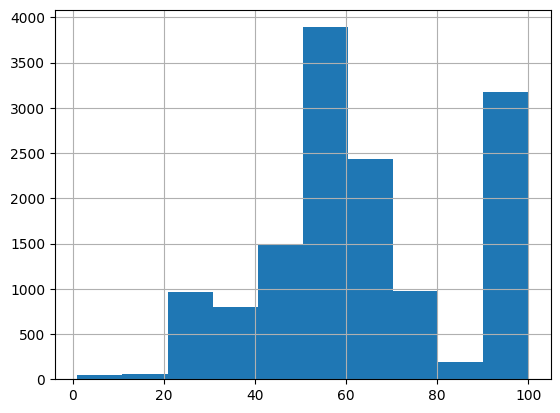

In [112]:
fichier_final_vote['voix_pct'].hist()

In [126]:
fichier_final_vote['id_election'].value_counts()

id_election
2014_muni_t1    9889
2020_muni_t1    2194
2008_muni_t1    1721
2014_muni_t2     209
2008_muni_t2       3
Name: count, dtype: int64

In [113]:
fichier_final_vote_ss_2008 = fichier_final_vote[(fichier_final_vote['annee']!= "2008") &
                                                    (fichier_final_vote['voix_pct'] > 50)
]

In [115]:
fichier_final_vote_ss_2008.shape

(9223, 38)

In [125]:
fichier_final_vote_ss_2008['id_election'].value_counts()

id_election
2014_muni_t1    6936
2020_muni_t1    2189
2014_muni_t2      98
Name: count, dtype: int64

In [116]:
table_code_insee_code_postal = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/correspondance-code-insee-code-postal.csv", sep = ";", dtype='str')
table_code_insee_code_postal = table_code_insee_code_postal[['Code INSEE', 'Code Postal']]

In [121]:
fichier_vote_avec_code_postal = pd.merge(
                fichier_final_vote_ss_2008,
                table_code_insee_code_postal,
                left_on = 'insee',
                right_on = 'Code INSEE',
                how = 'inner'
)

### vérifs des données

In [123]:
fichier_vote_avec_code_postal['id_election'].value_counts()

id_election
2014_muni_t1    5336
2020_muni_t1    2129
Name: count, dtype: int64

ici nombre de maire élus au premier tour en 2014
https://www.lemonde.fr/les-decodeurs/article/2014/03/24/qui-sont-les-maires-elus-des-le-premier-tour_4388664_4355770.html
Normalement 7606 dans les communes de + de 1000 habitants
Ici même pas 5600 .... 

en 2020, on devrait avoir 3700 communes environ, alors que là on en a 2600

In [102]:
print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2020_muni_t1'
]['Nuance_muni'].value_counts())

print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2020_muni_t1'
]['Nuance_muni'].shape)

print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2014_muni_t1'
]['Nuance_muni'].value_counts())

print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2014_muni_t1'
]['Nuance_muni'].shape)

Nuance_muni
LDVD    773
LDVG    465
LDIV    270
LDVC    266
LLR     113
LUG      74
LSOC     61
LCOM     36
LUDI     19
LUD      18
LECO      8
LUC       8
LRN       6
LREM      3
LREG      3
LRDG      2
LMDM      2
LVEC      1
LEXD      1
Name: count, dtype: int64
(2129,)
Nuance_muni
LDVD    2040
LDVG    1255
LDIV     991
LSOC     272
LUMP     218
LUG      183
LUD      140
LUDI     133
LCOM      44
LMDM      21
LUC       18
LFG       12
LVEC       4
LPG        3
LFN        1
LEXD       1
Name: count, dtype: int64
(5336,)


Il en manque pour 2014

On exporte temporairement un fichier pas clean

In [56]:
fichier_vote_avec_code_postal_clean = fichier_vote_avec_code_postal[['annee',
'ident_election_ville', 'Nuance_muni','voix_pct','Nuance_interco']]

In [57]:
fichier_vote_avec_code_postal_clean[(fichier_vote_avec_code_postal_clean['voix_pct'] < 55)].shape

(1792, 5)

<Axes: >

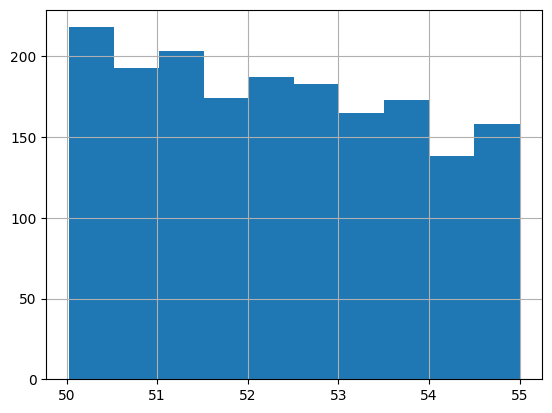

In [60]:
fichier_vote_avec_code_postal_clean[(fichier_vote_avec_code_postal_clean['voix_pct'] < 55)]['voix_pct'].hist()

In [58]:
fichier_vote_avec_code_postal_clean.to_csv("/home/onyxia/work/projet3A/donnees_electorales/donnees_muni_epci_completes.csv", index=False)